### accuracy for different satellite data   
(1) accuracy metrics.       
(2) result visualization.     


In [2]:
import glob    
import numpy as np     
import pandas as pd         
import seaborn as sns           
import rasterio as rio         
import cartopy.crs as ccrs        
from notebooks import config          
import matplotlib.pyplot as plt        
import matplotlib.ticker as mticker         
from utils.metrics import metrics_segm           
from matplotlib.colors import ListedColormap       
from pyrsimg import imsShow, imgShow, add_extent     

 

In [3]:
colors_gla = [
    (31/255, 36/255, 42/255),      # 非冰川：暗灰
    (140/255, 230/255, 255/255)    # 冰川：明亮冰蓝
    ]
colors_result = [
    (255/255, 255/255, 0/255),     # omission, value = -1, 黄色
    (31/255, 36/255, 42/255),      # non-glacier, value = 0， 深灰
    (140/255, 230/255, 255/255),   # glacier,  value = 1， 亮蓝
    (255/255, 0/255, 0/255),       # commission, value = 2， 红色
    ]
cmap_gla = ListedColormap(colors_gla)   
cmap_result = ListedColormap(colors_result)     


In [4]:
paths_val_scene = config.paths_scene_val
paths_val_truth = config.paths_truth_val
paths_val_dem = config.paths_dem_val
dir_result = 'data/result/u3net_cross_fusion/'
paths_val_result = sorted(glob.glob(dir_result + '*.tif'))
# paths_val_result     


In [5]:
## read data
scenes_arr, scenes_rio, truths, results = [], [], [], []
for path_scene,  path_truth, path_result in zip(paths_val_scene, paths_val_truth, paths_val_result):
    with rio.open(path_scene) as scene_rio:
        scene_arr = scene_rio.read()
        scene_arr = scene_arr.transpose((1, 2, 0))      ## (H,W,C)
        scenes_arr.append(scene_arr)
        scenes_rio.append(scene_rio)
    with rio.open(path_truth) as truth_rio:
        truth_arr = truth_rio.read()[0]                  ## (H,W)
        profile_truth = truth_rio.profile
        truths.append(truth_arr)
    with rio.open(path_result) as result_rio:
        result_arr = result_rio.read()[0]
        results.append(result_arr)


In [6]:
acc_metrics = pd.read_csv(dir_result + 'metrics_scenes.csv')
acc_metrics


,Unnamed: 0,miou,oa,kappa,f1_score,precision,recall
0,l5_scene_01,0.927978,0.981017,0.923899,0.961944,0.951245,0.973453
1,l5_scene_06,0.918276,0.980850,0.912747,0.956374,0.956502,0.956246
2,l5_scene_11,0.987541,0.993785,0.987462,0.993731,0.993591,0.993876
3,l7_scene_03,0.963953,0.981690,0.963294,0.981645,0.982314,0.981227
4,l7_scene_08,0.971105,0.986451,0.970649,0.985324,0.985298,0.985351
5,l7_scene_13,0.960728,0.992517,0.959436,0.979716,0.992111,0.968101
6,l8_scene_05,0.897633,0.992122,0.886935,0.943450,0.986401,0.907966
7,l8_scene_10,0.975566,0.990930,0.975182,0.987591,0.987373,0.987809
8,l9_scene_02,0.977494,0.997527,0.977033,0.988517,0.995514,0.981741
9,l9_scene_07,0.888279,0.979742,0.876890,0.938439,0.951330,0.926439


In [7]:
## classify by satellite name and calculate average accuracy
acc_data = acc_metrics[acc_metrics['Unnamed: 0'] != 'mean'].copy()
acc_data['satellite'] = acc_data['Unnamed: 0'].str.split('_').str[0]
sat_acc = acc_data.groupby('satellite')[['miou', 'oa', 'kappa', 'f1_score', 'precision', 'recall']].mean()
sat_acc.head()


,miou,oa,kappa,f1_score,precision,recall
satellite,,,,,,
l5,0.944598,0.985217,0.941370,0.970683,0.967113,0.974525
l7,0.965262,0.986886,0.964459,0.982228,0.986574,0.978227
l8,0.936600,0.991526,0.931058,0.965521,0.986887,0.947887
l9,0.947806,0.988696,0.943771,0.971884,0.978443,0.965699
s2,0.962309,0.996302,0.960585,0.980292,0.991099,0.970485


#### region selection

In [71]:
### l5
# i = 1
# extent_local = [75.82, 75.94, 37.465, 37.55]

# ### l7 
# i = 3
# extent_local = [-27.9, -27.25, 73.33, 73.5]

# ### l8
# i = 7
# extent_local = [-28., -27.3, 81.77, 81.87]

# ### l9
# i = 10
# extent_local = [-70.8, -70.2, 77.02, 77.15]

### s2
i = 12
extent_local = [-64.4, -64.24, 67.01, 67.07]


## identify the scene coordinates and extent    
scene_src = scenes_rio[i]    
epsg = scenes_rio[i].crs.to_epsg()    
src_crs = ccrs.epsg(epsg)     
extent_scene = [scene_src.bounds.left, scene_src.bounds.right, scene_src.bounds.bottom, scene_src.bounds.top]    
print(extent_scene)     


[433290.0, 451470.0, 7431810.0, 7448920.0]


Unnamed: 0    s2_scene_09
miou             0.981114
oa               0.996234
kappa            0.980823
f1_score         0.990412
precision        0.990051
recall           0.990774
Name: 12, dtype: object


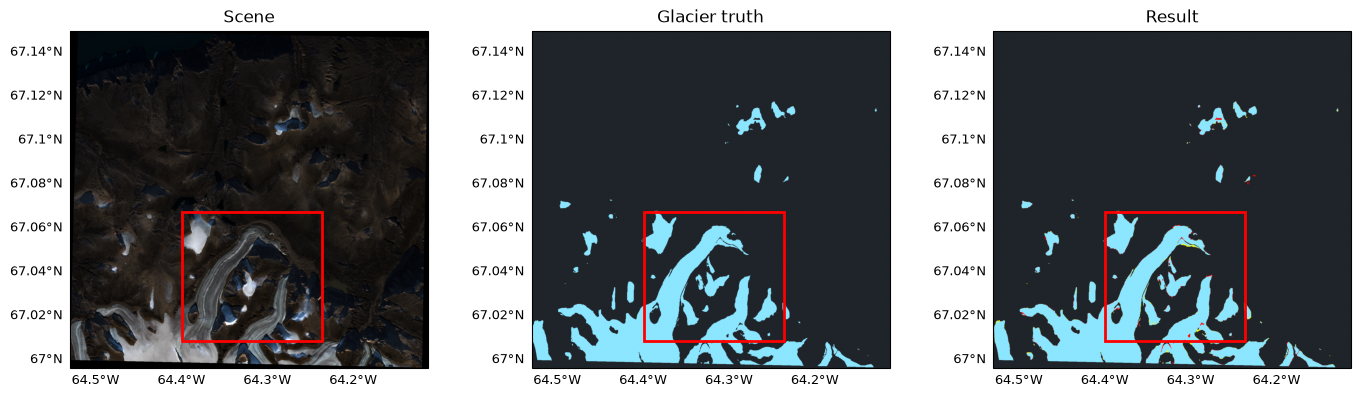

In [72]:
result = 2*results[i].astype(int) - truths[i]   ##  omission: -1, right non-gla: 0, right glaicer: 1, comission: 2

### show the scene and truth
fig, ax = plt.subplots(1, 3, figsize=(14, 4), subplot_kw={'projection': src_crs})
print(acc_metrics.iloc[i,:])       

imgShow(scenes_arr[i], color_bands = [2,1,0], clip_percent=[0, 100], extent=extent_scene, transform=src_crs, ax=ax[0])
ax[1].imshow(truths[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)  

## result
imgShow(scenes_arr[i], color_bands = [2,1,0], clip_percent=[0, 90], extent=extent_scene, transform=src_crs, ax=ax[2])
# ax[2].imshow(results[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)
ax[2].imshow(result,cmap=cmap_result, vmin=-1.5, vmax=2.5, extent=extent_scene, transform=src_crs)

for j, a in enumerate(ax):
    gl = a.gridlines(draw_labels=True, color="gray", alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"fontsize": 9}    
    gl.ylabel_style = {"fontsize": 9}   
    gl.geo_labels = False   # note: 禁止 Gridliner 调整标题  
    # gl.xlocator = mticker.MultipleLocator(0.3)   
    # gl.ylocator = mticker.MultipleLocator(0.5)   
    add_extent(a, extent_local, edgecolor="red", linewidth=2, extent_epsg='4326', ax_epsg=epsg)
ax[0].set_title("Scene")     
ax[1].set_title("Glacier truth")     
ax[2].set_title("Result")       
# ax[3].set_title("Local Glacier truth")       
plt.tight_layout()       


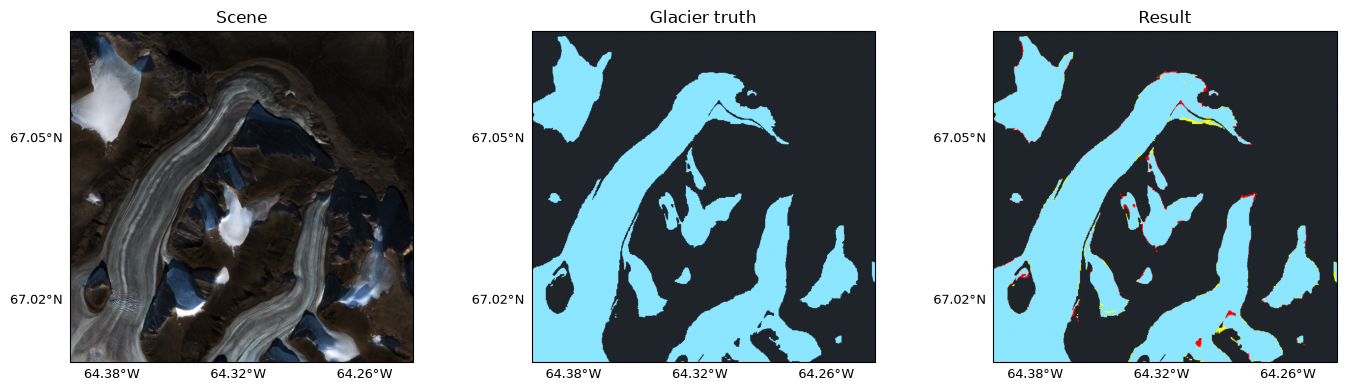

In [81]:
### show the scene, truth and result.
fig, ax = plt.subplots(1, 3, figsize=(14, 4), subplot_kw={'projection': src_crs})
## scene
imgShow(scenes_arr[i], color_bands = [2,1,0], clip_percent=[0, 100], extent=extent_scene, transform=src_crs, ax=ax[0])
## truth
ax[1].imshow(truths[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)  
## result
imgShow(scenes_arr[i], color_bands = [2,1,0], clip_percent=[0, 99], extent=extent_scene, transform=src_crs, ax=ax[2])
# ax[2].imshow(results[i], cmap=cmap_gla, vmin=-0.5, vmax=1.5, extent=extent_scene, transform=src_crs)
ax[2].imshow(result,cmap=cmap_result, vmin=-1.5, vmax=2.5, extent=extent_scene, transform=src_crs)

for j, a in enumerate(ax):
    gl = a.gridlines(draw_labels=True, color="gray", alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"fontsize": 9}    
    gl.ylabel_style = {"fontsize": 9}   
    gl.geo_labels = False     # note: 禁止 Gridliner 调整标题   
    a.set_extent(extent_local, crs=ccrs.PlateCarree())     
    gl.xlocator = mticker.MultipleLocator(0.06)
    gl.ylocator = mticker.MultipleLocator(0.03)

ax[0].set_title("Scene")     
ax[1].set_title("Glacier truth")     
ax[2].set_title("Result")      
plt.tight_layout()      

